# Results tables and figures

Tables and visualizations for the results section. Numbers are read from the
MLflow tracking store (`mlflow-data/`), not recomputed here, so every figure
matches what is logged on the run.

Runs are the same nine as `cara_bleu_rtc_story.ipynb`: four methods across two
backbones (Llama-3.3-70B-Instruct, Llama-3.1-8B-Instruct), plus CodeT5, each
evaluated on the same 2000 samples of the full dataset (Python + Java).

In [1]:
import mlflow
import pandas as pd

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = mlflow.MlflowClient()

# (method, backbone) -> MLflow run_uuid. Same registry as the story notebook.
RUNS = {
    ("zeroshot", "70B"): "3fc7ad1d11744ad1932039a162c675c3",
    ("few_shot", "70B"): "d1197c3c7e3841508625f4115ff9e999",
    ("asap", "70B"): "5005bca877e14c548c05676d439e74a2",
    ("cara", "70B"): "68e8ff6fc73848b091804af05a906622",
    ("zeroshot", "8B"): "38bf994f55064833b046902bba702297",
    ("few_shot", "8B"): "f39382e451594a448b50ef4cd4e49913",
    ("asap", "8B"): "93ac3d2df48c4933b189185db300fac6",
    ("cara", "8B"): "9f85a34ec20547caa6f917e8a49b6aad",
    ("codet5", None): "847b29e632ec4aa7a165f3137f1bbd6d",
}

DISPLAY_NAME = {
    "zeroshot": "Zero-shot",
    "few_shot": "Few-shot",
    "asap": "ASAP",
    "cara": "CARA",
    "codet5": "CodeT5",
}
GROUP_LABEL = {"70B": "Llama-3.3-70B", "8B": "Llama-3.1-8B", None: "Fine-tuned"}


def fetch_metrics() -> dict[tuple, dict[str, float]]:
    """Logged metrics for every run in RUNS, keyed the same way."""
    return {key: client.get_run(run_id).data.metrics for key, run_id in RUNS.items()}


METRICS = fetch_metrics()
print(f"loaded {len(METRICS)} runs")

loaded 9 runs


## Table 1 — reference-based metrics

BLEU, ROUGE-L, chrF and METEOR for every run, all on a 0-100 scale, grouped by
backbone with the best value in each group bolded.

- **BLEU** — sentence BLEU against the human reference summary.
- **ROUGE-L** — longest-common-subsequence F1. Logged 0-1 by the runner and
  scaled here so the columns are comparable.
- **chrF** — character n-gram F-score up to order 6, beta=2 (the standard
  weighting).
- **METEOR** — the official CMU METEOR 1.5 jar, run with `-norm`. Not nltk's
  `meteor_score`, which uses untuned METEOR 1.0 parameters and scores roughly
  twice as high on this data.

chrF and METEOR are computed by `mas_code_sum.metrics` and logged by the runner.
These nine runs predate that, so their values were added by
`scripts/backfill_chrf_meteor.py`, which calls the same functions — future runs
carry them natively.

In [2]:
# metric key -> (column label, scale factor onto 0-100)
REFERENCE_METRICS = {
    "bleu": ("BLEU", 1.0),
    "rougeL": ("ROUGE-L", 100.0),
    "chrf": ("chrF", 1.0),
    "meteor": ("METEOR", 1.0),
}


def metric_table(metric_spec: dict[str, tuple[str, float]]) -> pd.DataFrame:
    """One row per run, grouped by backbone."""
    index, rows = [], []
    for method, backbone in RUNS:
        index.append((GROUP_LABEL[backbone], DISPLAY_NAME[method]))
        rows.append(
            {
                label: METRICS[(method, backbone)][name] * scale
                for name, (label, scale) in metric_spec.items()
            }
        )
    return pd.DataFrame(
        rows, index=pd.MultiIndex.from_tuples(index, names=["Model", "Method"])
    )


def bold_best_per_group(table: pd.DataFrame) -> pd.DataFrame:
    """Bold the best value in each column within each backbone group.

    A group holding a single method is left unbolded: being best of one says
    nothing, and a fully bolded row reads as a win over the other groups.
    """
    styles = pd.DataFrame("", index=table.index, columns=table.columns)
    for _, block in table.groupby(level=0, sort=False):
        if len(block) < 2:
            continue
        for column in table.columns:
            styles.loc[block[column].idxmax(), column] = "font-weight:bold"
    return styles


table1 = metric_table(REFERENCE_METRICS)
table1.style.format("{:.2f}").apply(bold_best_per_group, axis=None)

## Table 2 — per-project, ASAP vs CARA (70B)

The two strongest methods from Table 1, broken out over the 20 projects (100
samples each) to show whether the aggregate picture holds project by project,
with a pooled **All projects** row over all 2000 samples at the bottom.

Per-project numbers are not logged on the runs, so these are recomputed from the
runs' `predictions` artifacts, matched on `(project, func_name, id)`. The metric
implementations come from `mas_code_sum` — `evaluator.bleu`, `rouge_score`, and
`metrics.chrf` / `metrics.meteor`, the same functions the runner scores with — so
a project's mean is directly comparable to the aggregate in Table 1.

**Significance.** Each project is tested with a paired Wilcoxon signed-rank test
over its 100 samples. With 20 projects tested per metric, p-values are
Holm-corrected *within each metric*, so significance accounts for testing all 20
projects rather than being read off a raw p-value. The **All projects** row is a
single test over all 2000 samples and is not part of that family, so its p-value
is uncorrected.

**`*` (bold)** — significantly higher than the other method at p < 0.05.
Where neither value is marked, the test does not separate them.

In [ ]:
import sys
from pathlib import Path

import numpy as np
from rouge_score import rouge_scorer
from scipy.stats import wilcoxon

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

# The same implementations the runner scores with and the backfill script logs,
# so per-project numbers here cannot drift from the metrics on the runs.
from mas_code_sum.evaluator import bleu as _bleu  # noqa: E402
from mas_code_sum.metrics import chrf, meteor  # noqa: E402

PAIR = {"ASAP": "asap", "CARA": "cara"}
ALPHA = 0.05


def load_predictions(method: str, backbone: str | None) -> pd.DataFrame:
    """Predictions artifact for a run, indexed by matched sample key."""
    run_id = RUNS[(method, backbone)]
    local_dir = Path(client.download_artifacts(run_id, "predictions"))
    (csv_path,) = local_dir.glob("*.csv")
    df = pd.read_csv(csv_path)
    for field in ["reference", "prediction"]:
        df[field] = df[field].fillna("")
    return df.set_index(["project", "func_name", "id"])


def per_sample_scores(df: pd.DataFrame) -> pd.DataFrame:
    """BLEU / ROUGE-L / chrF / METEOR for every row, all on a 0-100 scale."""
    refs, preds = df["reference"].tolist(), df["prediction"].tolist()
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    # `metrics.meteor` returns None when the jar is missing -- right for a
    # scoring run, but here it would silently blank out a whole table column.
    meteor_scores = meteor(refs, preds)
    assert meteor_scores is not None, "METEOR 1.5 jar not found -- set METEOR_JAR"
    return pd.DataFrame(
        {
            "BLEU": [100 * _bleu([r], p)[0] for r, p in zip(refs, preds)],
            "ROUGE-L": [100 * scorer.score(r, p)["rougeL"].fmeasure for r, p in zip(refs, preds)],
            "chrF": [chrf(r, p) for r, p in zip(refs, preds)],
            "METEOR": meteor_scores,
        },
        index=df.index,
    )


_SCORE_CACHE: dict[str, dict[str, pd.DataFrame]] = {}


def scores_for(backbone: str) -> dict[str, pd.DataFrame]:
    """Per-sample scores for ASAP and CARA on one backbone, on matched samples.

    Scoring a run costs a METEOR subprocess over 2000 segments, so results are
    cached -- calling this again for the same backbone is free.
    """
    if backbone not in _SCORE_CACHE:
        predictions = {
            name: load_predictions(method, backbone) for name, method in PAIR.items()
        }
        matched = predictions["ASAP"].index.intersection(predictions["CARA"].index)
        _SCORE_CACHE[backbone] = {
            name: per_sample_scores(df.loc[matched]) for name, df in predictions.items()
        }
        print(
            f"{backbone}: {len(matched)} matched samples across "
            f"{matched.get_level_values('project').nunique()} projects"
        )
    return _SCORE_CACHE[backbone]


def holm(pvalues: np.ndarray) -> np.ndarray:
    """Holm-Bonferroni adjusted p-values, in the input order."""
    order = np.argsort(pvalues)
    n = len(pvalues)
    adjusted = np.empty(n)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (n - rank) * pvalues[idx])
        adjusted[idx] = min(running, 1.0)
    return adjusted


In [4]:
METRIC_COLUMNS = ["BLEU", "ROUGE-L", "chrF", "METEOR"]
ALL_PROJECTS = "All projects"


def per_project_comparison(backbone: str) -> pd.DataFrame:
    """ASAP and CARA per project per metric, plus a pooled row.

    Where the paired test separates them, the winning value is marked with `*`
    (and bolded by the styler); where it does not, neither value is marked.

    The 20 per-project tests are Holm-corrected within each metric. The pooled
    row is a single test over all 2000 samples, so it is not part of that
    family and carries its own uncorrected p-value.
    """
    scores = scores_for(backbone)
    projects = sorted(scores["ASAP"].index.get_level_values("project").unique())
    columns, data = [], {}
    for metric in METRIC_COLUMNS:
        means = {"ASAP": [], "CARA": []}
        pvalues = []
        for project in projects:
            a = scores["ASAP"].xs(project, level="project")[metric]
            c = scores["CARA"].xs(project, level="project")[metric]
            difference = (c - a).to_numpy()
            means["ASAP"].append(a.mean())
            means["CARA"].append(c.mean())
            pvalues.append(
                wilcoxon(difference).pvalue if np.any(difference != 0) else 1.0
            )
        adjusted = list(holm(np.array(pvalues)))

        pooled = (scores["CARA"][metric] - scores["ASAP"][metric]).to_numpy()
        means["ASAP"].append(scores["ASAP"][metric].mean())
        means["CARA"].append(scores["CARA"][metric].mean())
        adjusted.append(wilcoxon(pooled).pvalue if np.any(pooled != 0) else 1.0)

        for label in ["ASAP", "CARA"]:
            other = "CARA" if label == "ASAP" else "ASAP"
            columns.append((metric, label))
            data[(metric, label)] = [
                f"{value:.2f}*" if p < ALPHA and value > rival else f"{value:.2f}"
                for value, rival, p in zip(means[label], means[other], adjusted)
            ]
    return pd.DataFrame(
        data,
        index=pd.Index(projects + [ALL_PROJECTS], name="Project"),
        columns=pd.MultiIndex.from_tuples(columns),
    )


def bold_significant(value: str) -> str:
    """Bold the marked value -- the one that is significantly higher."""
    return "font-weight:bold" if value.endswith("*") else ""


def style_comparison(table: pd.DataFrame):
    return table.style.map(bold_significant).set_properties(
        subset=pd.IndexSlice[[ALL_PROJECTS], :], **{"border-top": "2px solid #444"}
    )


table2 = per_project_comparison("70B")
style_comparison(table2)


70B: 2000 matched samples across 20 projects


## Table 3 — per-project, ASAP vs CARA (8B)

Table 2 repeated on the Llama-3.1-8B backbone, to show whether the per-project
pattern survives the drop in model scale. Same samples, same metrics, same
Holm-corrected per-project tests and uncorrected pooled row; only the backbone
differs.

In [5]:
table3 = per_project_comparison("8B")
style_comparison(table3)


8B: 2000 matched samples across 20 projects


## Figure 1 — summary length

Word count per summary for the reference and every method, as split horizontal
violins (seaborn) over the matched samples, so the shape of each length
distribution is visible rather than just its mean. Length is not a quality
metric on its own, but several of the metric differences in Tables 1-3 (chrF
and METEOR favoring CARA, BLEU and ROUGE-L favoring ASAP) track how far each
method's output sits from the reference's length, so it is worth seeing
directly.

Each method occupies one row, split by backbone: the **upper half** is
Llama-3.3-70B, the **lower half** Llama-3.1-8B. Reference and CodeT5 exist for
a single model each and are drawn as full, symmetric violins.

Inside each violin, the **dashed line** is the median and the **dotted lines**
are the first and third quartiles (`inner="quart"`), each spanning the violin's
width at that value.

All violins share one absolute KDE bandwidth (1.5 words) so their shapes are
comparable; seaborn's default would smooth each group differently. Violins are
scaled to a common maximum width rather than a common area, for the same
reason. The x-axis stops at 45 words, which leaves well under 1% of summaries
off-screen (the cell asserts this and prints the exact figure) — a handful of
runaway generations reach 128 words and would otherwise flatten every
distribution into a spike.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

MODEL_LABEL = {"70B": "Llama-3.3-70B", "8B": "Llama-3.1-8B"}
ROW_ORDER = ["Reference", "Zero-shot", "Few-shot", "ASAP", "CARA", "CodeT5"]

# Word counts are discrete and long-tailed, so every violin is smoothed with the
# same absolute KDE bandwidth. With seaborn's default per-group bandwidth the
# shapes would not be comparable, which is the whole point of one shared axis.
KDE_BANDWIDTH_WORDS = 1.5
X_LIMIT = 45  # the assertion below pins how much mass this leaves off-screen


def word_counts(method: str, backbone: str | None) -> pd.Series:
    """Prediction word counts for a run, one value per matched sample."""
    run_id = RUNS[(method, backbone)]
    local_dir = Path(client.download_artifacts(run_id, "predictions"))
    (csv_path,) = local_dir.glob("*.csv")
    df = pd.read_csv(csv_path)
    return df["prediction"].fillna("").str.split().str.len()


def reference_word_counts() -> pd.Series:
    """Reference word counts, one value per matched sample. The human summaries
    are shared across every run, so any run's `reference` column gives the same
    distribution; checked here rather than assumed."""
    means = []
    for method, backbone in RUNS:
        run_id = RUNS[(method, backbone)]
        local_dir = Path(client.download_artifacts(run_id, "predictions"))
        (csv_path,) = local_dir.glob("*.csv")
        means.append(
            pd.read_csv(csv_path)["reference"].fillna("").str.split().str.len().mean()
        )
    spread = max(means) - min(means)
    assert spread < 0.5, f"reference length varies across runs by {spread:.2f} words"
    run_id = RUNS[("cara", "70B")]
    local_dir = Path(client.download_artifacts(run_id, "predictions"))
    (csv_path,) = local_dir.glob("*.csv")
    return pd.read_csv(csv_path)["reference"].fillna("").str.split().str.len()


# Long format: one row per summary, with the model it came from.
frames = [pd.DataFrame({"method": "Reference", "model": "Reference", "words": reference_word_counts()})]
for method in ["zeroshot", "few_shot", "asap", "cara"]:
    for backbone in ["70B", "8B"]:
        frames.append(
            pd.DataFrame(
                {
                    "method": DISPLAY_NAME[method],
                    "model": MODEL_LABEL[backbone],
                    "words": word_counts(method, backbone),
                }
            )
        )
frames.append(pd.DataFrame({"method": "CodeT5", "model": "CodeT5", "words": word_counts("codet5", None)}))
lengths = pd.concat(frames, ignore_index=True)

clipped = (lengths["words"] > X_LIMIT).mean()
assert clipped < 0.01, f"x-axis clip hides {clipped:.1%} of the data"

0.41% of summaries fall beyond the 45-word axis limit


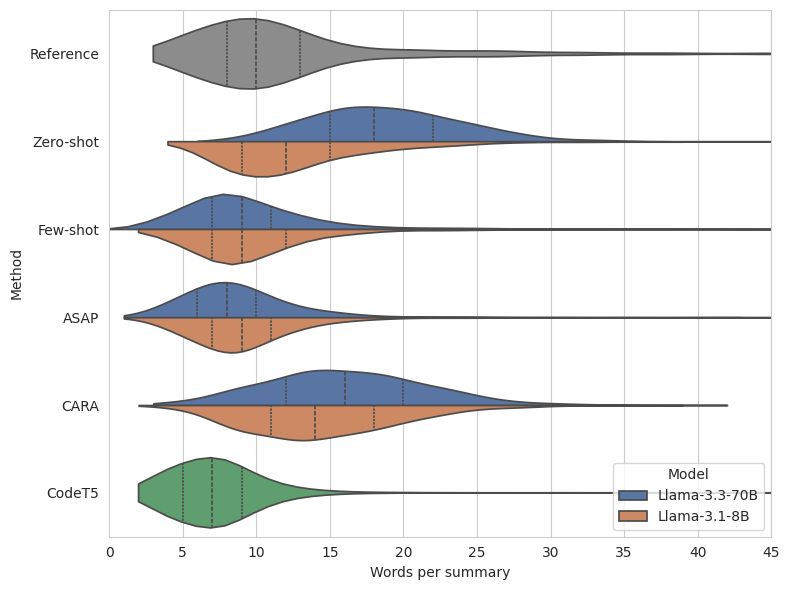

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

MODEL_LABEL = {"70B": "Llama-3.3-70B", "8B": "Llama-3.1-8B"}
ROW_ORDER = ["Reference", "Zero-shot", "Few-shot", "ASAP", "CARA", "CodeT5"]

# Word counts are discrete and long-tailed, so every violin is smoothed with the
# same absolute KDE bandwidth. With seaborn's default per-group bandwidth the
# shapes would not be comparable, which is the whole point of one shared axis.
KDE_BANDWIDTH_WORDS = 1.5
X_LIMIT = 45  # the assertion below pins how much mass this leaves off-screen


def word_counts(method: str, backbone: str | None) -> pd.Series:
    """Prediction word counts for a run, one value per matched sample."""
    run_id = RUNS[(method, backbone)]
    local_dir = Path(client.download_artifacts(run_id, "predictions"))
    (csv_path,) = local_dir.glob("*.csv")
    df = pd.read_csv(csv_path)
    return df["prediction"].fillna("").str.split().str.len()


def reference_word_counts() -> pd.Series:
    """Reference word counts, one value per matched sample. The human summaries
    are shared across every run, so any run's `reference` column gives the same
    distribution; checked here rather than assumed."""
    means = []
    for method, backbone in RUNS:
        run_id = RUNS[(method, backbone)]
        local_dir = Path(client.download_artifacts(run_id, "predictions"))
        (csv_path,) = local_dir.glob("*.csv")
        means.append(
            pd.read_csv(csv_path)["reference"].fillna("").str.split().str.len().mean()
        )
    spread = max(means) - min(means)
    assert spread < 0.5, f"reference length varies across runs by {spread:.2f} words"
    run_id = RUNS[("cara", "70B")]
    local_dir = Path(client.download_artifacts(run_id, "predictions"))
    (csv_path,) = local_dir.glob("*.csv")
    return pd.read_csv(csv_path)["reference"].fillna("").str.split().str.len()


# Long format: one row per summary, with the model it came from.
frames = [pd.DataFrame({"method": "Reference", "model": "Reference", "words": reference_word_counts()})]
for method in ["zeroshot", "few_shot", "asap", "cara"]:
    for backbone in ["70B", "8B"]:
        frames.append(
            pd.DataFrame(
                {
                    "method": DISPLAY_NAME[method],
                    "model": MODEL_LABEL[backbone],
                    "words": word_counts(method, backbone),
                }
            )
        )
frames.append(pd.DataFrame({"method": "CodeT5", "model": "CodeT5", "words": word_counts("codet5", None)}))
lengths = pd.concat(frames, ignore_index=True)

clipped = (lengths["words"] > X_LIMIT).mean()
assert clipped < 0.01, f"x-axis clip hides {clipped:.1%} of the data"

# Zero-shot / Few-shot / ASAP / CARA ran on both backbones and split their row.
# Reference and CodeT5 exist for a single model each; seaborn's split mode would
# draw those as a lone offset half, so they are drawn in a second call without
# a split -- a full symmetric violin -- on the same row order.
has_backbone = lengths["model"].isin(MODEL_LABEL.values())
# seaborn's "deep" palette, passed explicitly: only sns.set_theme() makes it the
# default, and that would restyle every later cell. Without it, hue falls back
# to matplotlib's brighter tab10 cycle.
deep = sns.color_palette("deep")
shared = dict(
    x="words",
    y="method",
    order=ROW_ORDER,
    orient="h",
    inner="quart",
    cut=0,
    # Every violin scaled to the same maximum width. The default "area" would
    # normalise each call separately, so the two calls would not be comparable.
    density_norm="width",
    # callable -> gaussian_kde factor, so this fixes the absolute bandwidth
    bw_method=lambda kde: KDE_BANDWIDTH_WORDS / np.std(kde.dataset),
)

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.violinplot(
        data=lengths[has_backbone],
        hue="model",
        hue_order=list(MODEL_LABEL.values()),
        palette={MODEL_LABEL["70B"]: deep[0], MODEL_LABEL["8B"]: deep[1]},
        split=True,
        ax=ax,
        **shared,
    )
    sns.violinplot(
        data=lengths[~has_backbone],
        hue="method",
        palette={"Reference": deep[7], "CodeT5": deep[2]},
        legend=False,
        ax=ax,
        **shared,
    )
    ax.set_xlim(0, X_LIMIT)
    ax.set_xlabel("Words per summary")
    ax.set_ylabel("Method")
    ax.legend(title="Model", loc="lower right")

    print(f"{clipped:.2%} of summaries fall beyond the {X_LIMIT}-word axis limit")
    plt.tight_layout()
    plt.show()
